# Model Tabular NOVA untuk Klasifikasi Risiko Stunting

## 1. Import Library

In [1]:
import pathlib
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from tensorflow.keras import layers, regularizers


## 2. Konfigurasi Path

In [2]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    # Path dataset ketika dijalankan pada Google Colab
    DATA_PATH = pathlib.Path("/content/drive/MyDrive/NOVA/data_bersih2.csv")

else:
    # Path dataset ketika dijalankan pada VS Code
    DATA_PATH = pathlib.Path("data_bersih_stunting2.csv")

print("Mode environment:", "Google Colab" if IN_COLAB else "VS Code / Lokal")
print("Path dataset:", DATA_PATH)

OUTPUT_DIR = pathlib.Path("output_model_stunting")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = OUTPUT_DIR / "stunting_model_tabular.keras"
BEST_MODEL_PATH = OUTPUT_DIR / "best_model_tabular.keras"

SCALER_PATH = OUTPUT_DIR / "scaler.pkl"
LABEL_ENCODER_PATH = OUTPUT_DIR / "label_encoder.pkl"
WILAYAH_ENCODER_PATH = OUTPUT_DIR / "wilayah_encoder.pkl"
FEATURE_COLUMNS_PATH = OUTPUT_DIR / "feature_columns.pkl"
NUMERIC_MEDIANS_PATH = OUTPUT_DIR / "numeric_medians.pkl"
CATEGORICAL_COLUMNS_PATH = OUTPUT_DIR / "categorical_columns.pkl"
WILAYAH_COLUMNS_PATH = OUTPUT_DIR / "wilayah_columns.pkl"


Mode environment: VS Code / Lokal
Path dataset: data_bersih_stunting2.csv


## 3. Load Dataset

In [3]:
print("Membaca dataset dari:", DATA_PATH)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset tidak ditemukan di path: {DATA_PATH}\n"
        "Silakan ubah DATA_PATH sesuai lokasi file dataset kamu."
    )

df = pd.read_csv(DATA_PATH)

print("\nInformasi awal dataset:")
print(df.info())

print("\n5 data pertama:")
print(df.head())


Membaca dataset dari: data_bersih_stunting2.csv

Informasi awal dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74305 entries, 0 to 74304
Data columns (total 41 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   NAMA_PROVINSI                  74305 non-null  object 
 1   NAMA_KECAMATAN                 74305 non-null  object 
 2   Ibu_Hamil                      74305 non-null  int64  
 3   Usia_Anak_0-23-Bln_            74305 non-null  int64  
 4   Bumil_cek_4kali_               74305 non-null  int64  
 5   Bumil_Pil_FE_                  74305 non-null  int64  
 6   Bumil_NIFAS_3kali              74305 non-null  int64  
 7   Bumil_Konseling_Gizi_4kali     74305 non-null  int64  
 8   Bumil_KEK                      74305 non-null  int64  
 9   Bumil_KEK_Kunjungan            74305 non-null  int64  
 10  Bumil_RESTI                    74305 non-null  int64  
 11  Bumil_RESTI_Kunjungan          74

## 4. Persiapan Target dan Pelabelan Risiko

In [4]:
TARGET_SOURCE_COL = "Indeks_Risiko_Stunting"
TARGET_COL = "Risk_Category"

if TARGET_SOURCE_COL not in df.columns:
    raise ValueError(
        f"Kolom target '{TARGET_SOURCE_COL}' tidak ditemukan. "
        "Pastikan nama kolom sesuai dengan dataset kamu."
    )

df[TARGET_SOURCE_COL] = pd.to_numeric(df[TARGET_SOURCE_COL], errors="coerce")
df = df.dropna(subset=[TARGET_SOURCE_COL]).copy()

risk_labels = ["Aman", "Waspada", "Prioritas Intervensi"]

try:
    df[TARGET_COL] = pd.qcut(
        df[TARGET_SOURCE_COL],
        q=3,
        labels=risk_labels,
        duplicates="drop",
    )
except ValueError:
    df[TARGET_COL] = pd.cut(
        df[TARGET_SOURCE_COL],
        bins=3,
        labels=risk_labels,
        include_lowest=True,
    )

print("\nDistribusi kategori risiko:")
print(df[TARGET_COL].value_counts())



Distribusi kategori risiko:
Risk_Category
Aman                    24771
Prioritas Intervensi    24769
Waspada                 24765
Name: count, dtype: int64


## 5. Preprocessing Data

In [5]:
drop_cols = [
    TARGET_COL,
    TARGET_SOURCE_COL,
]

wilayah_cols = [
    col for col in ["NAMA_PROVINSI", "NAMA_KECAMATAN"]
    if col in df.columns
]


def convert_object_number_columns(dataframe): #mengubah kolom objek dari persen menjadi numerik
    dataframe = dataframe.copy()

    for col in dataframe.columns:
        if dataframe[col].dtype == "object":
            cleaned = (
                dataframe[col]
                .astype(str)
                .str.replace("%", "", regex=False)
                .str.replace(",", ".", regex=False)
                .str.strip()
            )
            converted = pd.to_numeric(cleaned, errors="coerce")

            if converted.notna().mean() > 0.8:
                dataframe[col] = converted

    return dataframe


def prepare_features_for_training(df_source): # kelas untuk preprocessing data training
    X_df = df_source.drop(columns=drop_cols, errors="ignore").copy()
    X_df = convert_object_number_columns(X_df)

    for col in wilayah_cols: # mengisi missing value pada fitur wilayah
        if col in X_df.columns:
            X_df[col] = X_df[col].fillna("Tidak_Diketahui").astype(str)

    wilayah_encoder = None
    if wilayah_cols:
        wilayah_encoder = OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        )
        X_df[wilayah_cols] = wilayah_encoder.fit_transform(X_df[wilayah_cols])

    numeric_cols = X_df.select_dtypes(
        include=["int64", "float64", "int32", "float32"]
    ).columns.tolist()

    categorical_cols = [col for col in X_df.columns if col not in numeric_cols]

    numeric_medians = {}
    for col in numeric_cols:
        median_value = X_df[col].median()
        numeric_medians[col] = median_value
        X_df[col] = X_df[col].fillna(median_value)

    for col in categorical_cols:
        X_df[col] = X_df[col].fillna("Tidak_Diketahui").astype(str)

    # encoding untuk kategori kecil
    X_df = pd.get_dummies(
        X_df,
        columns=categorical_cols,
        drop_first=True,
    )

    X_df = X_df.replace([np.inf, -np.inf], np.nan) # membersihkan nilai infinity

    for col in X_df.columns:
        if X_df[col].isna().sum() > 0:
            X_df[col] = X_df[col].fillna(X_df[col].median())

    X_df = X_df.clip(lower=-1e6, upper=1e6)
    X_df = X_df.astype("float32")

    return X_df, wilayah_encoder, numeric_medians, categorical_cols


def prepare_features_for_inference(sample_df): # kelas preprocessing untuk data baru saat inference
    feature_columns = joblib.load(FEATURE_COLUMNS_PATH)
    numeric_medians = joblib.load(NUMERIC_MEDIANS_PATH)
    categorical_cols = joblib.load(CATEGORICAL_COLUMNS_PATH)
    saved_wilayah_cols = joblib.load(WILAYAH_COLUMNS_PATH)

    sample_processed = sample_df.drop(columns=drop_cols, errors="ignore").copy()
    sample_processed = convert_object_number_columns(sample_processed)

    
    if saved_wilayah_cols: # encode fitur wilayah menggunakan encoder yang sama dengan training tadi
        wilayah_encoder = joblib.load(WILAYAH_ENCODER_PATH)

        for col in saved_wilayah_cols:
            if col not in sample_processed.columns:
                sample_processed[col] = "Tidak_Diketahui"

            sample_processed[col] = (
                sample_processed[col]
                .fillna("Tidak_Diketahui")
                .astype(str)
            )

        sample_processed[saved_wilayah_cols] = wilayah_encoder.transform(
            sample_processed[saved_wilayah_cols]
        )

    for col, median_value in numeric_medians.items():
        if col not in sample_processed.columns:
            sample_processed[col] = median_value
        sample_processed[col] = pd.to_numeric(
            sample_processed[col],
            errors="coerce"
        ).fillna(median_value)

    for col in categorical_cols:
        if col not in sample_processed.columns:
            sample_processed[col] = "Tidak_Diketahui"
        sample_processed[col] = sample_processed[col].fillna("Tidak_Diketahui").astype(str)

    sample_processed = pd.get_dummies(
        sample_processed,
        columns=categorical_cols,
        drop_first=True,
    )

    sample_processed = sample_processed.reindex(
        columns=feature_columns,
        fill_value=0,
    )

    return sample_processed.astype("float32")


## 6. Preprocessing pada Data Training

In [6]:
y = df[TARGET_COL].astype(str).copy()

X_df, wilayah_encoder, numeric_medians, categorical_cols = prepare_features_for_training(df)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X = X_df.values.astype("float32")
num_classes = len(label_encoder.classes_)

print("\nKelas target:", list(label_encoder.classes_))
print("Fitur wilayah yang dipakai:", wilayah_cols)
print("Jumlah fitur kategorikal setelah pemisahan:", len(categorical_cols))
print("Fitur kategorikal:", categorical_cols)
print("Jumlah fitur setelah preprocessing:", X.shape[1])



Kelas target: ['Aman', 'Prioritas Intervensi', 'Waspada']
Fitur wilayah yang dipakai: ['NAMA_PROVINSI', 'NAMA_KECAMATAN']
Jumlah fitur kategorikal setelah pemisahan: 0
Fitur kategorikal: []
Jumlah fitur setelah preprocessing: 40


## 7. Split Data Train, Validation, dan Test

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
)

print("\nUkuran data:")
print("Train      :", X_train.shape)
print("Validation :", X_val.shape)
print("Test       :", X_test.shape)



Ukuran data:
Train      : (52013, 40)
Validation : (11146, 40)
Test       : (11146, 40)


## 8. Scaling Fitur

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype("float32")
X_val_scaled = scaler.transform(X_val).astype("float32")
X_test_scaled = scaler.transform(X_test).astype("float32")


## 9. Membuat tf.data Dataset

In [9]:
BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_scaled, y_train))
    .shuffle(buffer_size=min(len(X_train_scaled), 10000))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    tf.data.Dataset.from_tensor_slices((X_val_scaled, y_val))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    tf.data.Dataset.from_tensor_slices((X_test_scaled, y_test))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)


## 10. Custom Layer

In [10]:
class ResidualDenseBlock(layers.Layer):
    def __init__(self, units, dropout_rate=0.3, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.dropout_rate = dropout_rate

        self.dense = layers.Dense(
            units,
            activation="relu",
            kernel_regularizer=regularizers.l2(0.001),
        )
        self.batch_norm = layers.BatchNormalization()
        self.dropout = layers.Dropout(dropout_rate)
        self.projection = None

    def build(self, input_shape):
        if input_shape[-1] != self.units:
            self.projection = layers.Dense(self.units, use_bias=False)
        super().build(input_shape)

    def call(self, inputs, training=False):
        x = self.dense(inputs)
        x = self.batch_norm(x, training=training)
        x = self.dropout(x, training=training)

        shortcut = inputs
        if self.projection is not None:
            shortcut = self.projection(inputs)

        return layers.Activation("relu")(x + shortcut)


## 11. Custom Loss Function

In [11]:
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])

        y_pred = tf.clip_by_value(
            y_pred,
            tf.keras.backend.epsilon(),
            1.0 - tf.keras.backend.epsilon(),
        )

        pt = tf.reduce_sum(y_true_one_hot * y_pred, axis=-1)
        loss = -alpha * tf.pow(1.0 - pt, gamma) * tf.math.log(pt)

        return tf.reduce_mean(loss)

    return loss_fn


## 12. Custom Callback

In [12]:
class StopAtHighAccuracy(tf.keras.callbacks.Callback):
    def __init__(self, target_accuracy=0.95):
        super().__init__()
        self.target_accuracy = target_accuracy

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        val_acc = logs.get("val_accuracy")

        if val_acc is not None and val_acc >= self.target_accuracy:
            print(
                f"\nValidation accuracy sudah mencapai {val_acc:.4f}. "
                "Training dihentikan agar tidak overfitting."
            )
            self.model.stop_training = True


## 13. Membangun Model dengan TensorFlow Functional API

In [13]:
input_dim = X_train_scaled.shape[1]
inputs = layers.Input(shape=(input_dim,), name="input_features")

x = ResidualDenseBlock(256, dropout_rate=0.35)(inputs)
x = ResidualDenseBlock(128, dropout_rate=0.30)(x)
x = ResidualDenseBlock(64, dropout_rate=0.25)(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    num_classes,
    activation="softmax",
    name="risk_category",
)(x)

model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="nova_stunting_risk_model",
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=focal_loss(gamma=2.0, alpha=0.25),
    metrics=["accuracy"],
)

print("\nRingkasan model:")
model.summary()




Ringkasan model:


Model: "nova_stunting_risk_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_features (InputLayer)     │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_dense_block            │ (None, 256)            │        21,760 │
│ (ResidualDenseBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_dense_block_1          │ (None, 128)            │        66,176 │
│ (ResidualDenseBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ residual_dense_block_2          │ (None, 64)             │        16,704 │
│ (ResidualDenseBlock)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ risk_category (Dense)           │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,819 (417.26 KB)

 Trainable params: 105,923 (413.76 KB)

 Non-trainable params: 896 (3.50 KB)

## 14. Training Model

In [14]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=12,
        restore_best_weights=True,
        verbose=1,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1,
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
    tf.keras.callbacks.TensorBoard(
        log_dir=str(OUTPUT_DIR / "logs"),
        histogram_freq=1,
    ),
    StopAtHighAccuracy(target_accuracy=0.95),
]

EPOCHS = 30

print("\nMemulai training model...")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)



Memulai training model...
Epoch 1/30
813/813 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7594 - loss: 0.2733
Epoch 1: val_accuracy improved from None to 0.93101, saving model to output_model_stunting\best_model_tabular.keras
813/813 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - accuracy: 0.8342 - loss: 0.1714 - val_accuracy: 0.9310 - val_loss: 0.0500 - learning_rate: 0.0010
Epoch 2/30
812/813 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9061 - loss: 0.0411
Epoch 2: val_accuracy did not improve from 0.93101
813/813 ━━━━━━━━━━━━━━━━━━━━ 13s 16ms/step - accuracy: 0.9111 - loss: 0.0329 - val_accuracy: 0.9104 - val_loss: 0.0223 - learning_rate: 0.0010
Epoch 3/30
812/813 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9262 - loss: 0.0197
Epoch 3: val_accuracy improved from 0.93101 to 0.95667, saving model to output_model_stunting\best_model_tabular.keras

Validation accuracy sudah mencapai 0.9567. Training dihentikan agar tidak overfitting.
813/813 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy

## 15. Evaluasi Model

In [15]:
print("\nEvaluasi pada data test:")
test_loss, test_acc = model.evaluate(test_ds, verbose=1)

print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")

y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Macro F1-score    : {macro_f1:.4f}")
print(f"Weighted F1-score : {weighted_f1:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_,
    )
)



Evaluasi pada data test:
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9586 - loss: 0.0127

Test Loss     : 0.0127
Test Accuracy : 0.9586
349/349 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Macro F1-score    : 0.9583
Weighted F1-score : 0.9583

Classification Report:
                      precision    recall  f1-score   support

                Aman       0.95      0.99      0.97      3716
Prioritas Intervensi       0.97      0.97      0.97      3715
             Waspada       0.96      0.92      0.94      3715

            accuracy                           0.96     11146
           macro avg       0.96      0.96      0.96     11146
        weighted avg       0.96      0.96      0.96     11146



## 16. Visualisasi Learning Curve

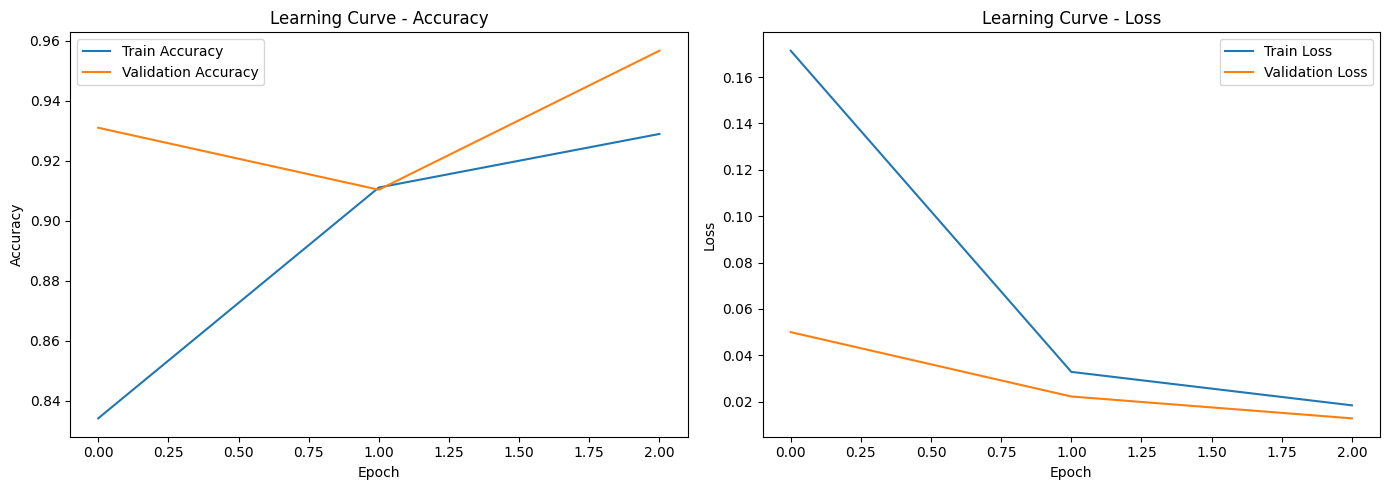


Learning curve berhasil disimpan.


In [21]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# accuracy
axs[0].plot(history.history["accuracy"], label="Train Accuracy")
axs[0].plot(history.history["val_accuracy"], label="Validation Accuracy")
axs[0].set_title("Learning Curve - Accuracy")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Accuracy")
axs[0].legend()

# loss
axs[1].plot(history.history["loss"], label="Train Loss")
axs[1].plot(history.history["val_loss"], label="Validation Loss")
axs[1].set_title("Learning Curve - Loss")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].legend()

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "learning_curve_combined.png",
    dpi=300
)

plt.show()
plt.close()
print("\nLearning curve berhasil disimpan.")


## 17. Confusion Matrix

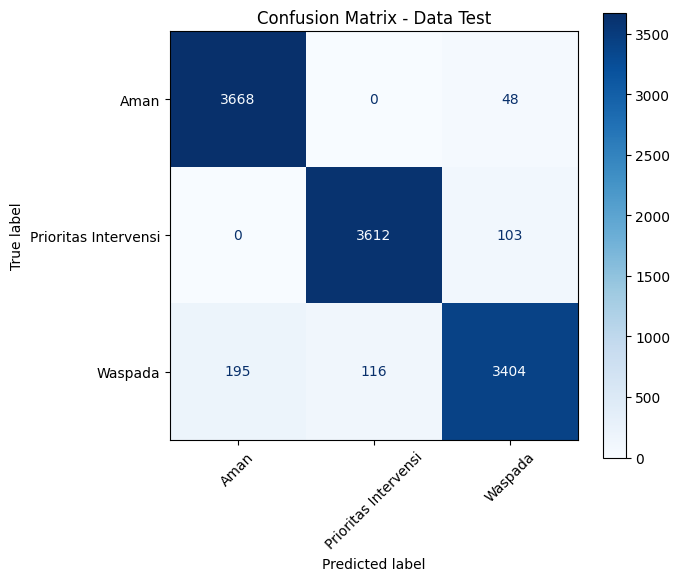

Confusion matrix berhasil disimpan.


In [22]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_,
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Data Test")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=300)
plt.show()
plt.close()

print("Confusion matrix berhasil disimpan.")


## 18. Menyimpan Model dan Objek Preprocessing

In [18]:
model.save(MODEL_PATH)

joblib.dump(scaler, SCALER_PATH)
joblib.dump(label_encoder, LABEL_ENCODER_PATH)
joblib.dump(list(X_df.columns), FEATURE_COLUMNS_PATH)
joblib.dump(numeric_medians, NUMERIC_MEDIANS_PATH)
joblib.dump(categorical_cols, CATEGORICAL_COLUMNS_PATH)
joblib.dump(wilayah_cols, WILAYAH_COLUMNS_PATH)

if wilayah_encoder is not None:
    joblib.dump(wilayah_encoder, WILAYAH_ENCODER_PATH)

print("\nModel dan file pendukung berhasil disimpan:")
print("Model           :", MODEL_PATH)
print("Best model      :", BEST_MODEL_PATH)
print("Scaler          :", SCALER_PATH)
print("Label encoder   :", LABEL_ENCODER_PATH)
print("Feature columns :", FEATURE_COLUMNS_PATH)
print("Wilayah encoder :", WILAYAH_ENCODER_PATH if wilayah_encoder is not None else "Tidak ada fitur wilayah")



Model dan file pendukung berhasil disimpan:
Model           : output_model_stunting\stunting_model_tabular.keras
Best model      : output_model_stunting\best_model_tabular.keras
Scaler          : output_model_stunting\scaler.pkl
Label encoder   : output_model_stunting\label_encoder.pkl
Feature columns : output_model_stunting\feature_columns.pkl
Wilayah encoder : output_model_stunting\wilayah_encoder.pkl


## 19. Fungsi Inference

In [19]:
def predict_stunting_risk(sample_df):
    loaded_scaler = joblib.load(SCALER_PATH)
    loaded_label_encoder = joblib.load(LABEL_ENCODER_PATH)

    sample_processed = prepare_features_for_inference(sample_df)
    sample_scaled = loaded_scaler.transform(sample_processed).astype("float32")

    probs = model.predict(sample_scaled)
    pred_idx = np.argmax(probs, axis=1)[0]

    predicted_label = loaded_label_encoder.inverse_transform([pred_idx])[0]
    confidence = float(np.max(probs[0]))

    probabilities = {
        label: float(prob)
        for label, prob in zip(loaded_label_encoder.classes_, probs[0])
    }

    return predicted_label, confidence, probabilities


## 20. Percobaan Inference

In [20]:
print("\nContoh inference:")

sample_original = df.drop(columns=[TARGET_COL], errors="ignore").iloc[[0]]
pred_label, confidence, pred_probs = predict_stunting_risk(sample_original)

print("Prediksi kategori risiko:", pred_label)
print(f"Confidence             : {confidence:.2%}")
print("Probabilitas           :", pred_probs)


print("\nPipeline model tabular selesai dijalankan.")



Contoh inference:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Prediksi kategori risiko: Aman
Confidence             : 99.95%
Probabilitas           : {'Aman': 0.9995061159133911, 'Prioritas Intervensi': 1.7061263860029818e-11, 'Waspada': 0.0004938390920870006}

Pipeline model tabular selesai dijalankan.


e:\BerkasNBL\Project_Plan\Project_Plan_AI\.venv\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
